In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [5]:
df = pd.read_csv("monthly_milk_production.csv")
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [6]:
print(df.shape)
df.info()

(168, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [7]:
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [8]:
date_col = None
for col in df.columns:
    if "month" in col.lower() or "date" in col.lower() or "time" in col.lower():
        date_col = col
        break

print("Detected date column:", date_col)

Detected date column: Date


In [9]:
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)

In [10]:
# Detect numeric column
value_col = df.select_dtypes(include=['float64','int64']).columns[0]

print("Detected numeric column:", value_col)


Detected numeric column: Production


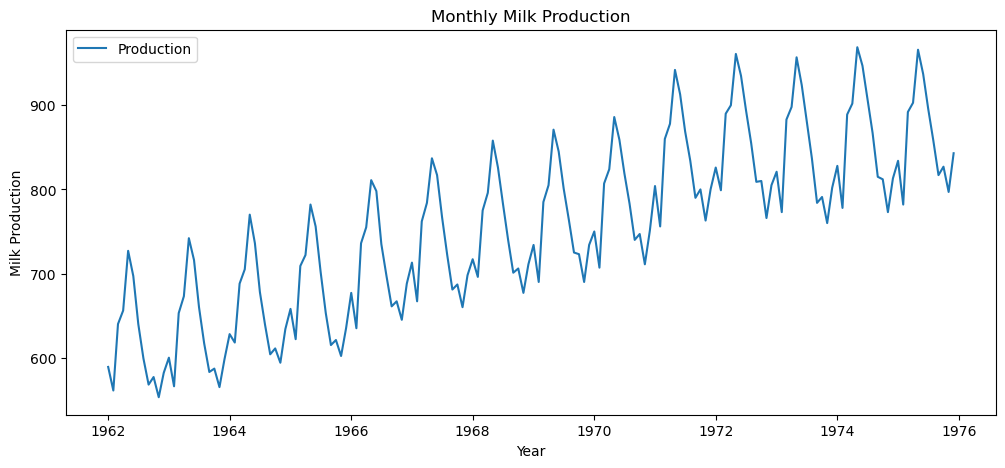

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df[value_col], label=value_col)
plt.title("Monthly Milk Production")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

In [12]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[[value_col]])

In [13]:
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)
window = 12
X, y = create_sequences(scaled_data, window)

In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 12, 1)
y shape: (156, 1)


In [15]:
train_size = int(len(X) * 0.80)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
X_train.shape, X_test.shape

((124, 12, 1), (32, 12, 1))

In [16]:
# RNN Model
rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.summary()

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_rnn = rnn_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0574 - val_loss: 0.0092
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0151 - val_loss: 0.0289
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0070 - val_loss: 0.0083
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0054 - val_loss: 0.0140
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0051 - val_loss: 0.0046
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0024 - val_loss: 0.0063
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0023 - val_loss: 0.0029
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0018 - val_loss: 0.0021
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0016 - val_loss: 0.0028
E

In [18]:
# LSTM Model
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_lstm = lstm_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.1361 - val_loss: 0.1678
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0381 - val_loss: 0.0257
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0301 - val_loss: 0.0288
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0256 - val_loss: 0.0332
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0251 - val_loss: 0.0375
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0238 - val_loss: 0.0289
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0230 - val_loss: 0.0252
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0233 - val_loss: 0.0255
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0227 - val_loss: 0.0278
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0223 - val_loss: 0.0259
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0220 - val_loss: 0.0243
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0215 - val_loss: 0.0246
E

In [20]:
gru_model = Sequential([
    GRU(64, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 64)                  │          12,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_gru = gru_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.1353 - val_loss: 0.1624
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0373 - val_loss: 0.0285
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0309 - val_loss: 0.0250
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0286 - val_loss: 0.0322
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0241 - val_loss: 0.0450
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0246 - val_loss: 0.0415
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0233 - val_loss: 0.0308
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0223 - val_loss: 0.0279
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0219 - val_loss: 0.0285
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0213 - val_loss: 0.0289
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0208 - val_loss: 0.0302
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0203 - val_loss: 0.0285
E

In [22]:
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    pred = scaler.inverse_transform(pred)
    actual = scaler.inverse_transform(y_test)
    
    rmse = math.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    
    return rmse, mae, pred

In [23]:
rnn_rmse, rnn_mae, rnn_pred = evaluate(rnn_model, X_test, y_test)
rnn_rmse, rnn_mae

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


(19.352381469024305, 15.339954376220692)

In [24]:
lstm_rmse, lstm_mae, lstm_pred = evaluate(lstm_model, X_test, y_test)
lstm_rmse, lstm_mae

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step


(32.46459415656995, 27.046920776367177)

In [25]:
gru_rmse, gru_mae, gru_pred = evaluate(gru_model, X_test, y_test)
gru_rmse, gru_mae

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step


(33.15219171602355, 27.529579162597646)

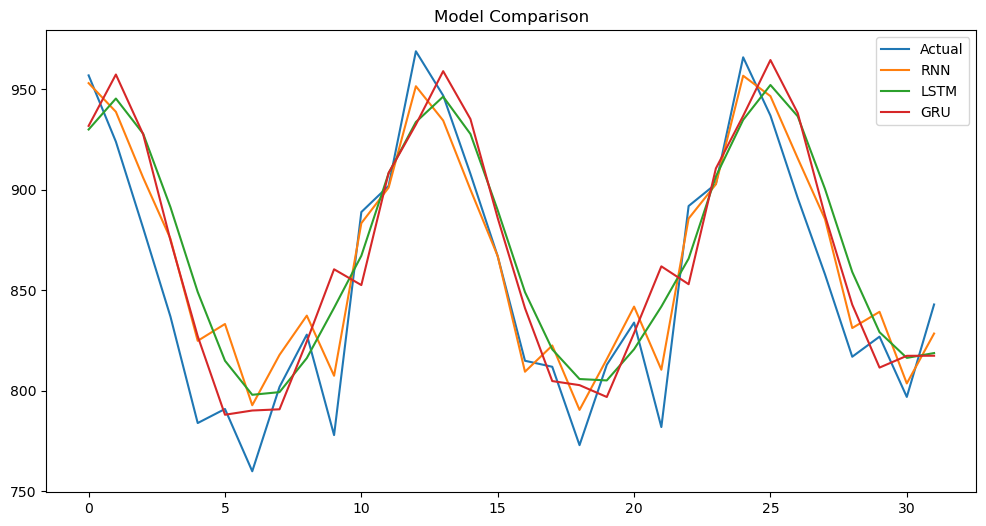

In [26]:
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(y_test), label="Actual")
plt.plot(rnn_pred, label="RNN")
plt.plot(lstm_pred, label="LSTM")
plt.plot(gru_pred, label="GRU")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [27]:
def forecast_next(model, last_seq, steps=12):
    result = []
    seq = last_seq.copy()

    for _ in range(steps):
        pred = model.predict(seq.reshape(1,window,1))[0]
        result.append(pred)
        seq = np.append(seq[1:], pred).reshape(window,1)
    return np.array(result)

In [28]:
last_seq = scaled_data[-window:]
future = forecast_next(lstm_model, last_seq, 12)
future = scaler.inverse_transform(future)
future

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[836.62616],
       [851.0627 ],
       [888.52814],
       [914.0341 ],
       [936.67096],
       [936.8016 ],
       [922.7093 ],
       [900.28687],
       [876.7405 ],
       [862.7787 ],
       [850.48615],
       [854.12195]], dtype=float32)

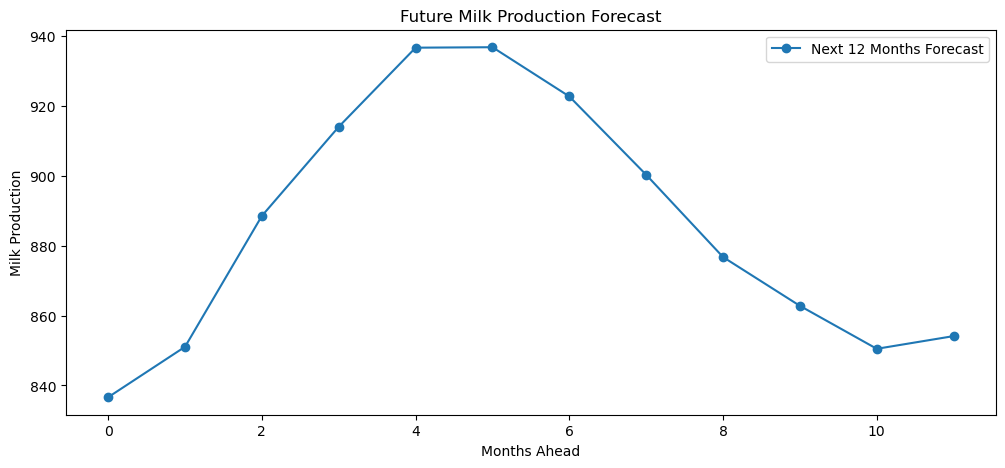

In [29]:
plt.figure(figsize=(12,5))
plt.plot(future, marker='o', label='Next 12 Months Forecast')
plt.title("Future Milk Production Forecast")
plt.xlabel("Months Ahead")
plt.ylabel("Milk Production")
plt.legend()
plt.show()